In [2]:
#packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import os

import numpy as np
# The first import of matplotlib can take some time (especially on cloud platforms). This is normal.
import matplotlib
import matplotlib.pyplot as plt

from pycbc.types.timeseries import TimeSeries
from pycbc.frame import read_frame
from pycbc.filter import resample_to_delta_t, highpass
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.waveform import get_td_waveform
from pycbc.filter import matched_filter
from pycbc.vetoes import power_chisq
from pycbc.events.ranking import newsnr

import bilby
from bilby.core.prior import Uniform, PowerLaw
from bilby.gw.conversion import convert_to_lal_binary_black_hole_parameters, generate_all_bbh_parameters

file_name = "challenge3.gwf"
URL = "https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf"

channel_format = "{ifo}:CHALLENGE3"

# Parameters of pre-processing steps
highpass_cutoff = 15.0
downsample_freq = 2048
strain_crop     = 2

# Parameters for PSD computation
welch_segment_length = 4

# Waveform parameters
waveform_cutoff = 20

# SNR
snr_crop = 4

# Reweighted SNR
nbins = 26
dof = nbins * 2 - 2

#source information
m_min = 10 #Msol
m_max = 50 #Msol
#recommended: mass range with logsteps between 10 and 50
spin = 0

event_duration = 8

n_masses = 10
masses_grid = np.logspace(np.log10(m_min), np.log10(m_max), n_masses)
print(masses_grid)

[10.         11.95813175 14.29969148 17.09975947 20.44811765 24.45212848
 29.24017738 34.96578934 41.81255155 50.        ]


In [3]:
#downloading the data source
if not os.path.isfile(file_name):
  print("Downloading data file")
  import urllib
  urllib.request.urlretrieve(URL, file_name)
  print('Getting : {}'.format(URL))
else:
  print("No downloading")

Getting : https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf


Signal for H1: duration=4092.0s, delta_t=0.00048828125s, delta_f=0.00024437927663734115Hz (sampling rate=2048.0Hz)
Signal for L1: duration=4092.0s, delta_t=0.00048828125s, delta_f=0.00024437927663734115Hz (sampling rate=2048.0Hz)


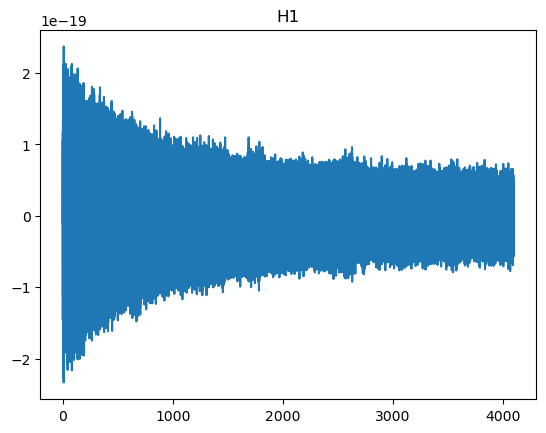

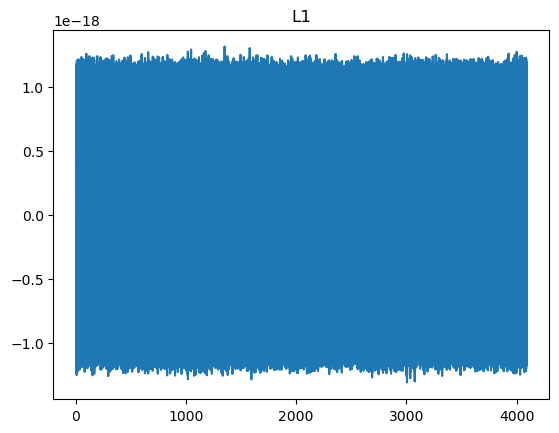

In [4]:
def read_and_preprocess(file_name, ifo):
    ts = read_frame(file_name, channel_format.format(ifo=ifo))
    strain = resample_to_delta_t(
        highpass(ts, highpass_cutoff),
        1/downsample_freq
    )
    strain = strain.crop(strain_crop, strain_crop)
    return strain

data = {}
for ifo_name in ['H1', 'L1']:
    strain = read_and_preprocess(file_name, ifo_name)
    print(f"Signal for {ifo_name}: duration={strain.duration}s, delta_t={strain.delta_t}s, delta_f={strain.delta_f}Hz (sampling rate={1/strain.delta_t}Hz)")
    data[ifo_name] = strain
    plt.figure()
    strain.plot()
    plt.title(ifo_name)

In [5]:
# Check some candidates events
candidate_times = [
    3219.18,
    196.0,
    1101.40,
    1637,
    2892.7
]

# Q transform
q_transforms = {}
for ifo_name in ['H1', 'L1']:
    t, f, p = data[ifo_name].whiten(4, 4).qtransform(.001, logfsteps=100, qrange=(8, 8), frange=(20, 512))
    q_transforms[ifo_name] = (t, f, p)

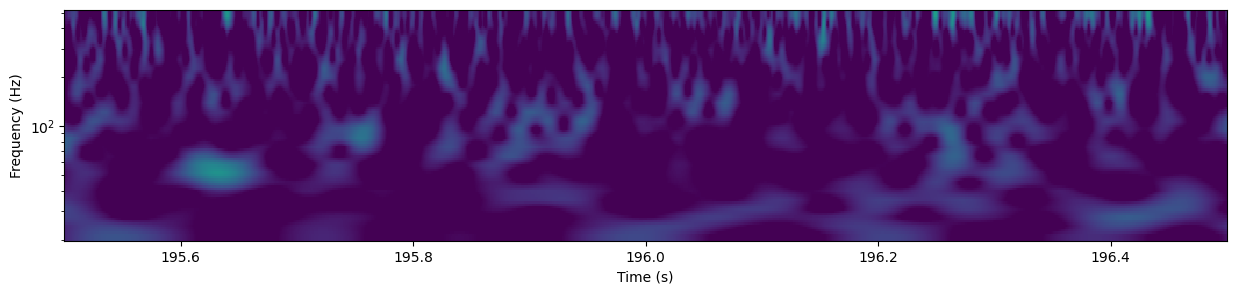

In [ ]:
# Plot Q transform
time = candidate_times[1]
for ifo_name in ['H1', 'L1']:
    (t, f, p) = q_transforms[ifo_name]
    plt.figure(figsize=[15, 3])
    plt.pcolormesh(t, f, p**0.5, vmin=1, vmax=6, shading='auto')
    plt.yscale('log')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.xlim(time - 0.5, time + 0.5)
    plt.show()